<a href="https://colab.research.google.com/github/hawkh/Livestockify/blob/main/yolov11chicken.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="sNp5UMXhqMRvnjxaBIue")
project = rf.workspace("cornell-university-gxjqt").project("chicken-all")
version = project.version(1)
dataset = version.download("yolov11", location="/content/roboflow_dataset")
!ls /content/roboflow_dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/roboflow_dataset in yolov11:: 100%|██████████| 3434/3434 [00:00<00:00, 5527.95it/s]


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.1/112.6 GB disk)


In [ ]:
# Create a directory for hyperparameters if it doesn't exist
import os
os.makedirs('/content/hyps', exist_ok=True)

# Define the hyperparameters content as a multi-line string
hyp_contents = """
# Custom Hyperparameters for YOLOv11 Training

lr0: 0.01        # Initial learning rate
lrf: 0.1         # Final learning rate (lr0 * lrf)
momentum: 0.937  # SGD momentum
weight_decay: 0.0005  # Optimizer weight decay
warmup_epochs: 3.0    # Number of warmup epochs
warmup_momentum: 0.8  # Warmup initial momentum
warmup_bias_lr: 0.1   # Warmup initial bias learning rate

# Augmentation Hyperparameters
flipud: 0.0      # Vertical flip probability
fliplr: 0.5      # Horizontal flip probability
mosaic: 1.0      # Mosaic augmentation probability
mixup: 0.2       # MixUp augmentation probability
degrees: 10.0    # Rotation degrees
translate: 0.1   # Translation fraction
scale: 0.5       # Scale fraction
shear: 2.0       # Shear degrees
perspective: 0.0 # Perspective transformation
hsv_h: 0.015     # HSV-Hue augmentation
hsv_s: 0.7       # HSV-Saturation augmentation
hsv_v: 0.4       # HSV-Value augmentation
copy_paste: 0.1  # Copy-paste augmentation probability
"""

# Write the hyperparameters to the YAML file
with open('/content/hyps/hyp_custom.yaml', 'w') as f:
    f.write(hyp_contents)


In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11m.pt')

100%|██████████| 38.8M/38.8M [00:00<00:00, 130MB/s]


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [ ]:
%cd /content
!yolo task=detect mode=train model=yolo11m.pt data=/content/roboflow_dataset/data.yaml \
  epochs=20 imgsz=1280 batch=2 augment=True lr0=0.01 lrf=0.1 momentum=0.937 weight_decay=0.0005 \
  warmup_epochs=3 warmup_momentum=0.8 warmup_bias_lr=0.1 flipud=0.1 fliplr=0.5 mosaic=1.0 mixup=0.3 \
  degrees=20 translate=0.3 scale=0.5 shear=5 perspective=0.001 hsv_h=0.015 hsv_s=0.8 hsv_v=0.6 \
  copy_paste=0.2 multi_scale=True plots=True

# !yolo task=detect mode=train model=yolo11n.pt data=/content/roboflow_dataset/data.yaml epochs=50 imgsz=640 batch=16 augment=True lr0=0.01 lrf=0.1 momentum=0.937 weight_decay=0.0005 warmup_epochs=3 warmup_momentum=0.8 warmup_bias_lr=0.1 flipud=0.0 fliplr=0.5 mosaic=1.0 mixup=0.2 degrees=10 translate=0.1 scale=0.5 shear=2 perspective=0.0 hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 copy_paste=0.1 plots=True
# !yolo task=detect mode=train model=yolo11n.pt data=/content/roboflow_dataset/data.yaml epochs=10 imgsz=640 augment=True hyp=/content/hyps/hyp_custom.yaml plots=True

/content
New https://pypi.org/project/ultralytics/8.3.163 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/content/roboflow_dataset/data.yaml, epochs=20, time=None, patience=100, batch=2, imgsz=1280, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=True, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data=/content/roboflow_dataset/data.yaml epochs=50 imgsz=640 batch=16 augment=True hyp=/content/hyps/hyp_custom.yaml plots=True

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 903, in entrypoint
    check_dict_alignment(full_args_dict, overrides)
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 485, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: 'hyp' is not a valid YOLO argument. 

    Arguments received: ['yolo', 'task=detect', 'mode=train', 'model=yolo11n.pt', 'data=/content/roboflow_dataset/data.yaml', 'epochs=50', 'imgsz=640', 'batch=16', 'augment=True', 'hyp=/content/hyps/hyp_custom.yaml', 'plots=True']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'obb', 'detect', 'classify', 'segment', 'pose'}
                MODE (required) is one of {'track', 'benchmark', 'export', 'val', 'tra

In [ ]:
!ls /content/runs/detect/train/

args.yaml					    train_batch1.jpg
confusion_matrix_normalized.png			    train_batch2.jpg
confusion_matrix.png				    train_batch6730.jpg
events.out.tfevents.1752222117.d78601f5997e.1577.0  train_batch6731.jpg
F1_curve.png					    train_batch6732.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
P_curve.png					    val_batch1_labels.jpg
PR_curve.png					    val_batch1_pred.jpg
R_curve.png					    val_batch2_labels.jpg
results.csv					    val_batch2_pred.jpg
results.png					    weights
train_batch0.jpg


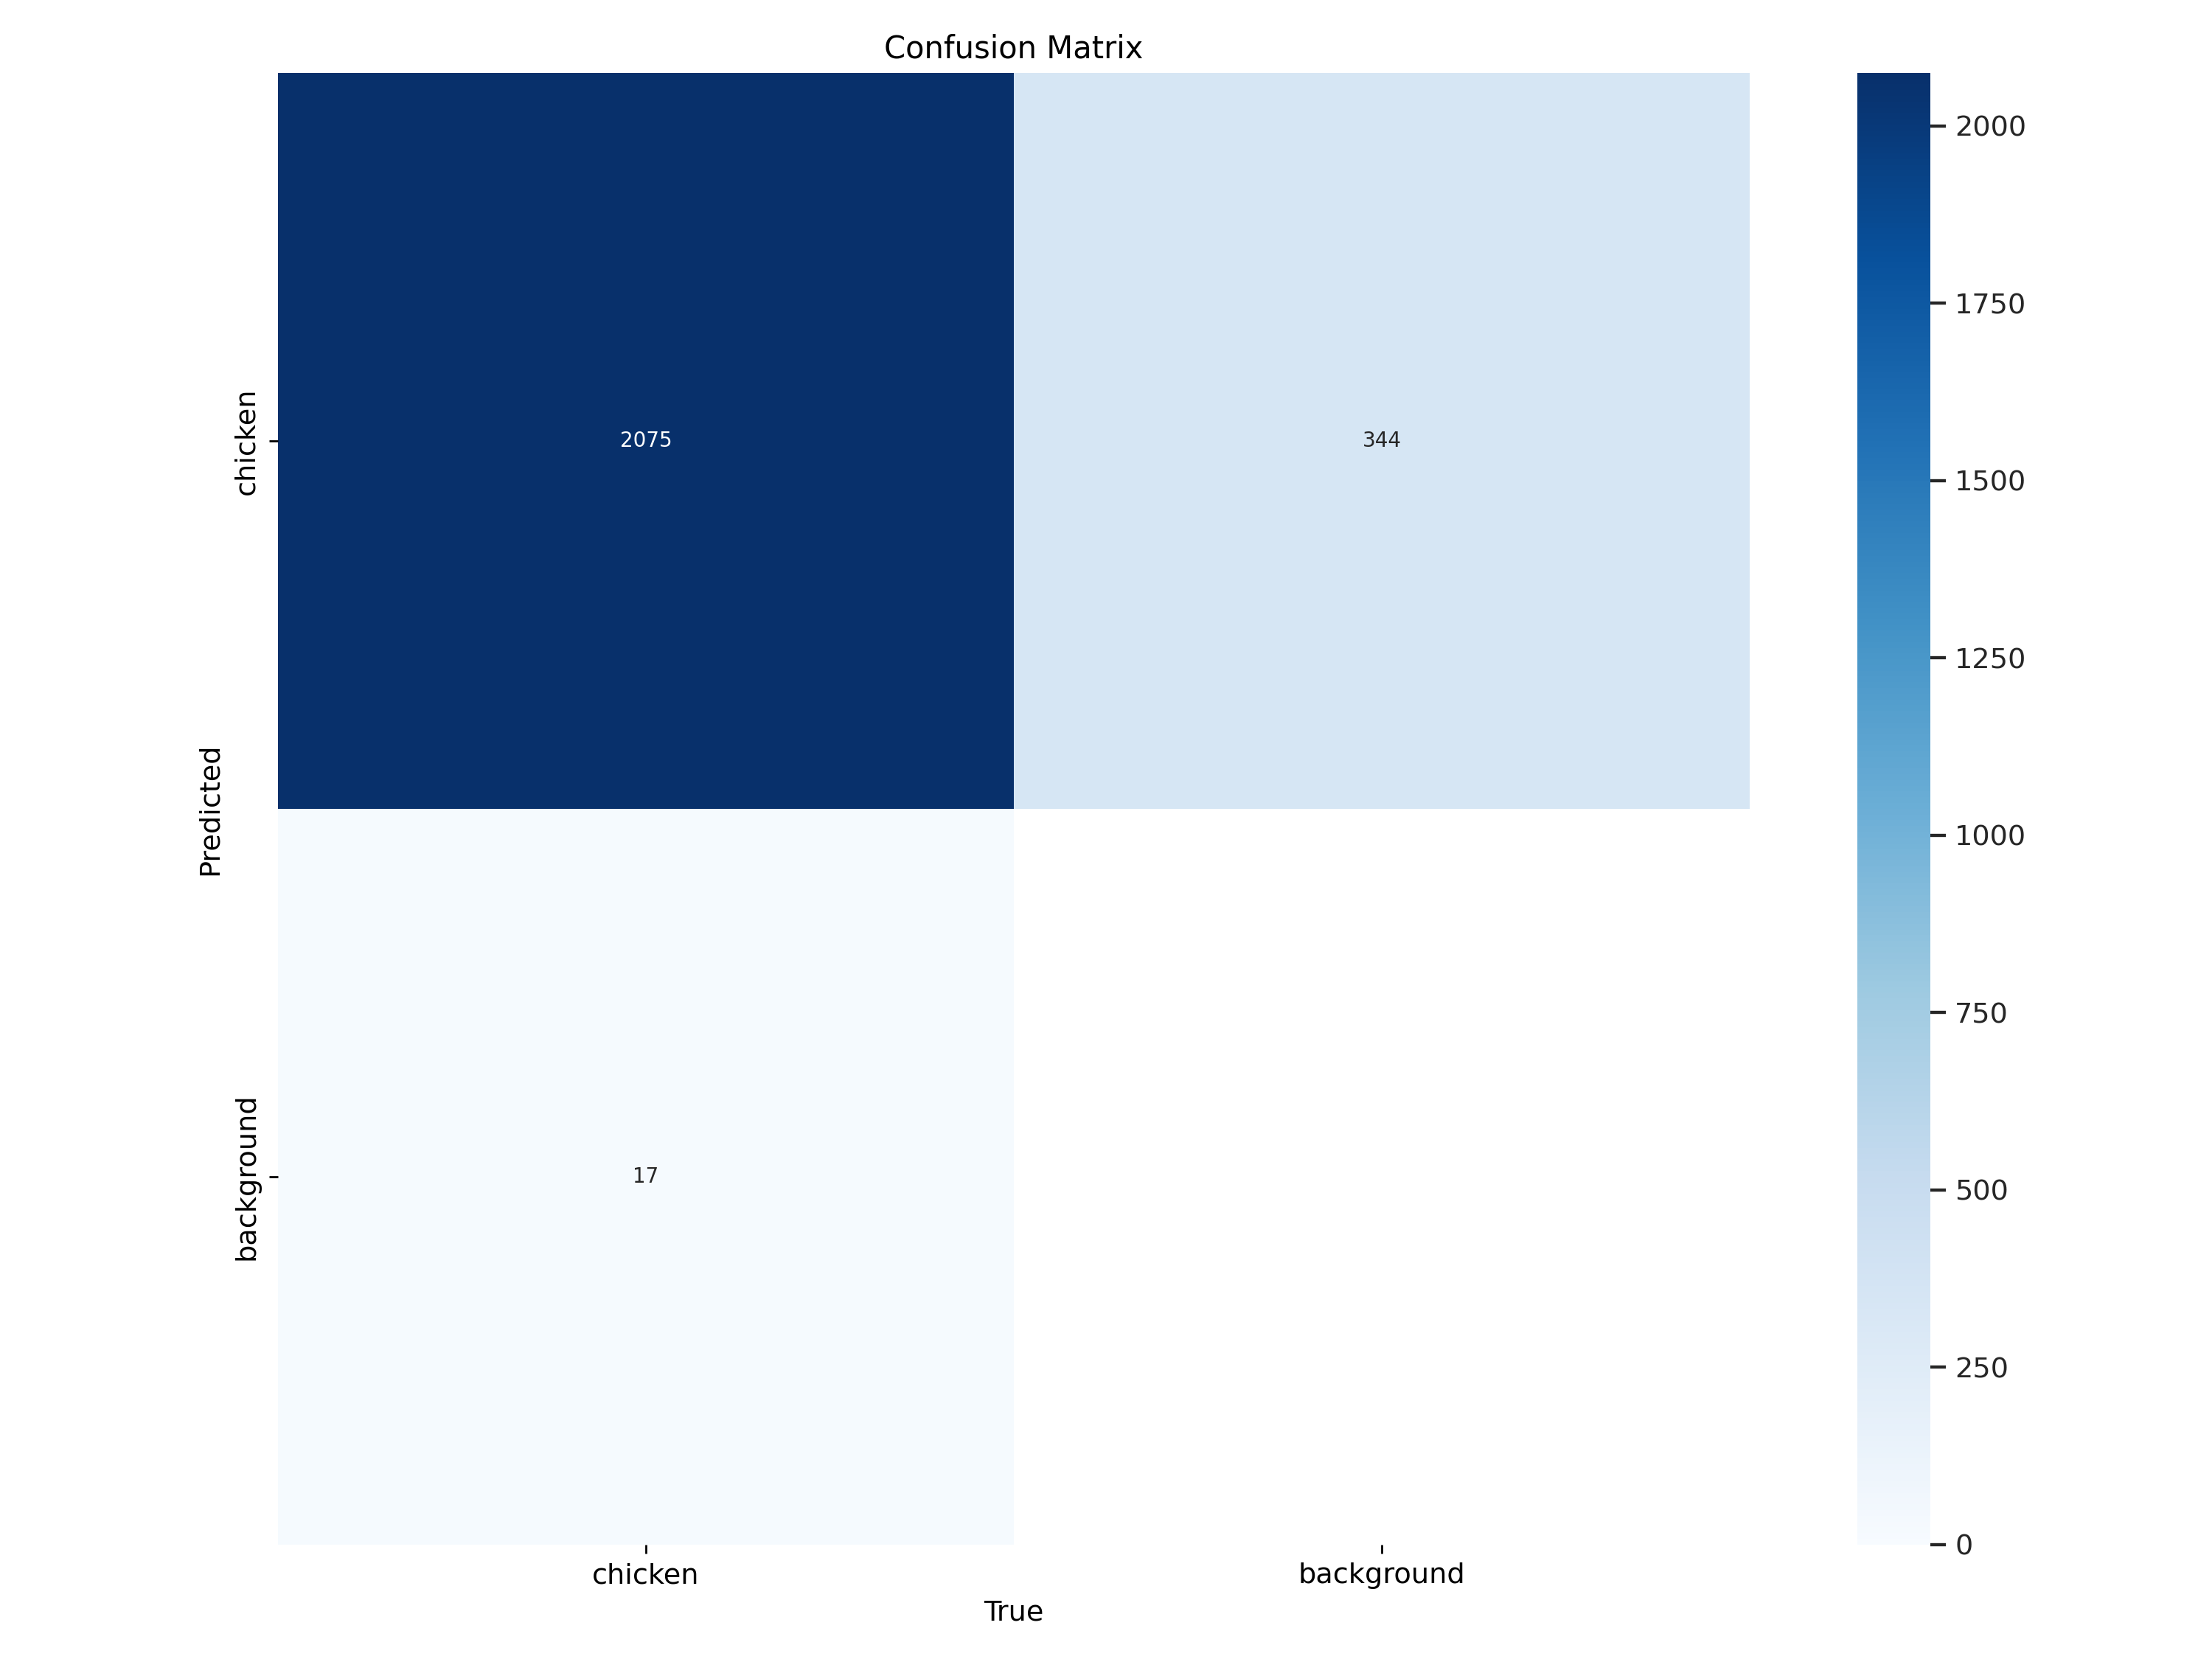

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

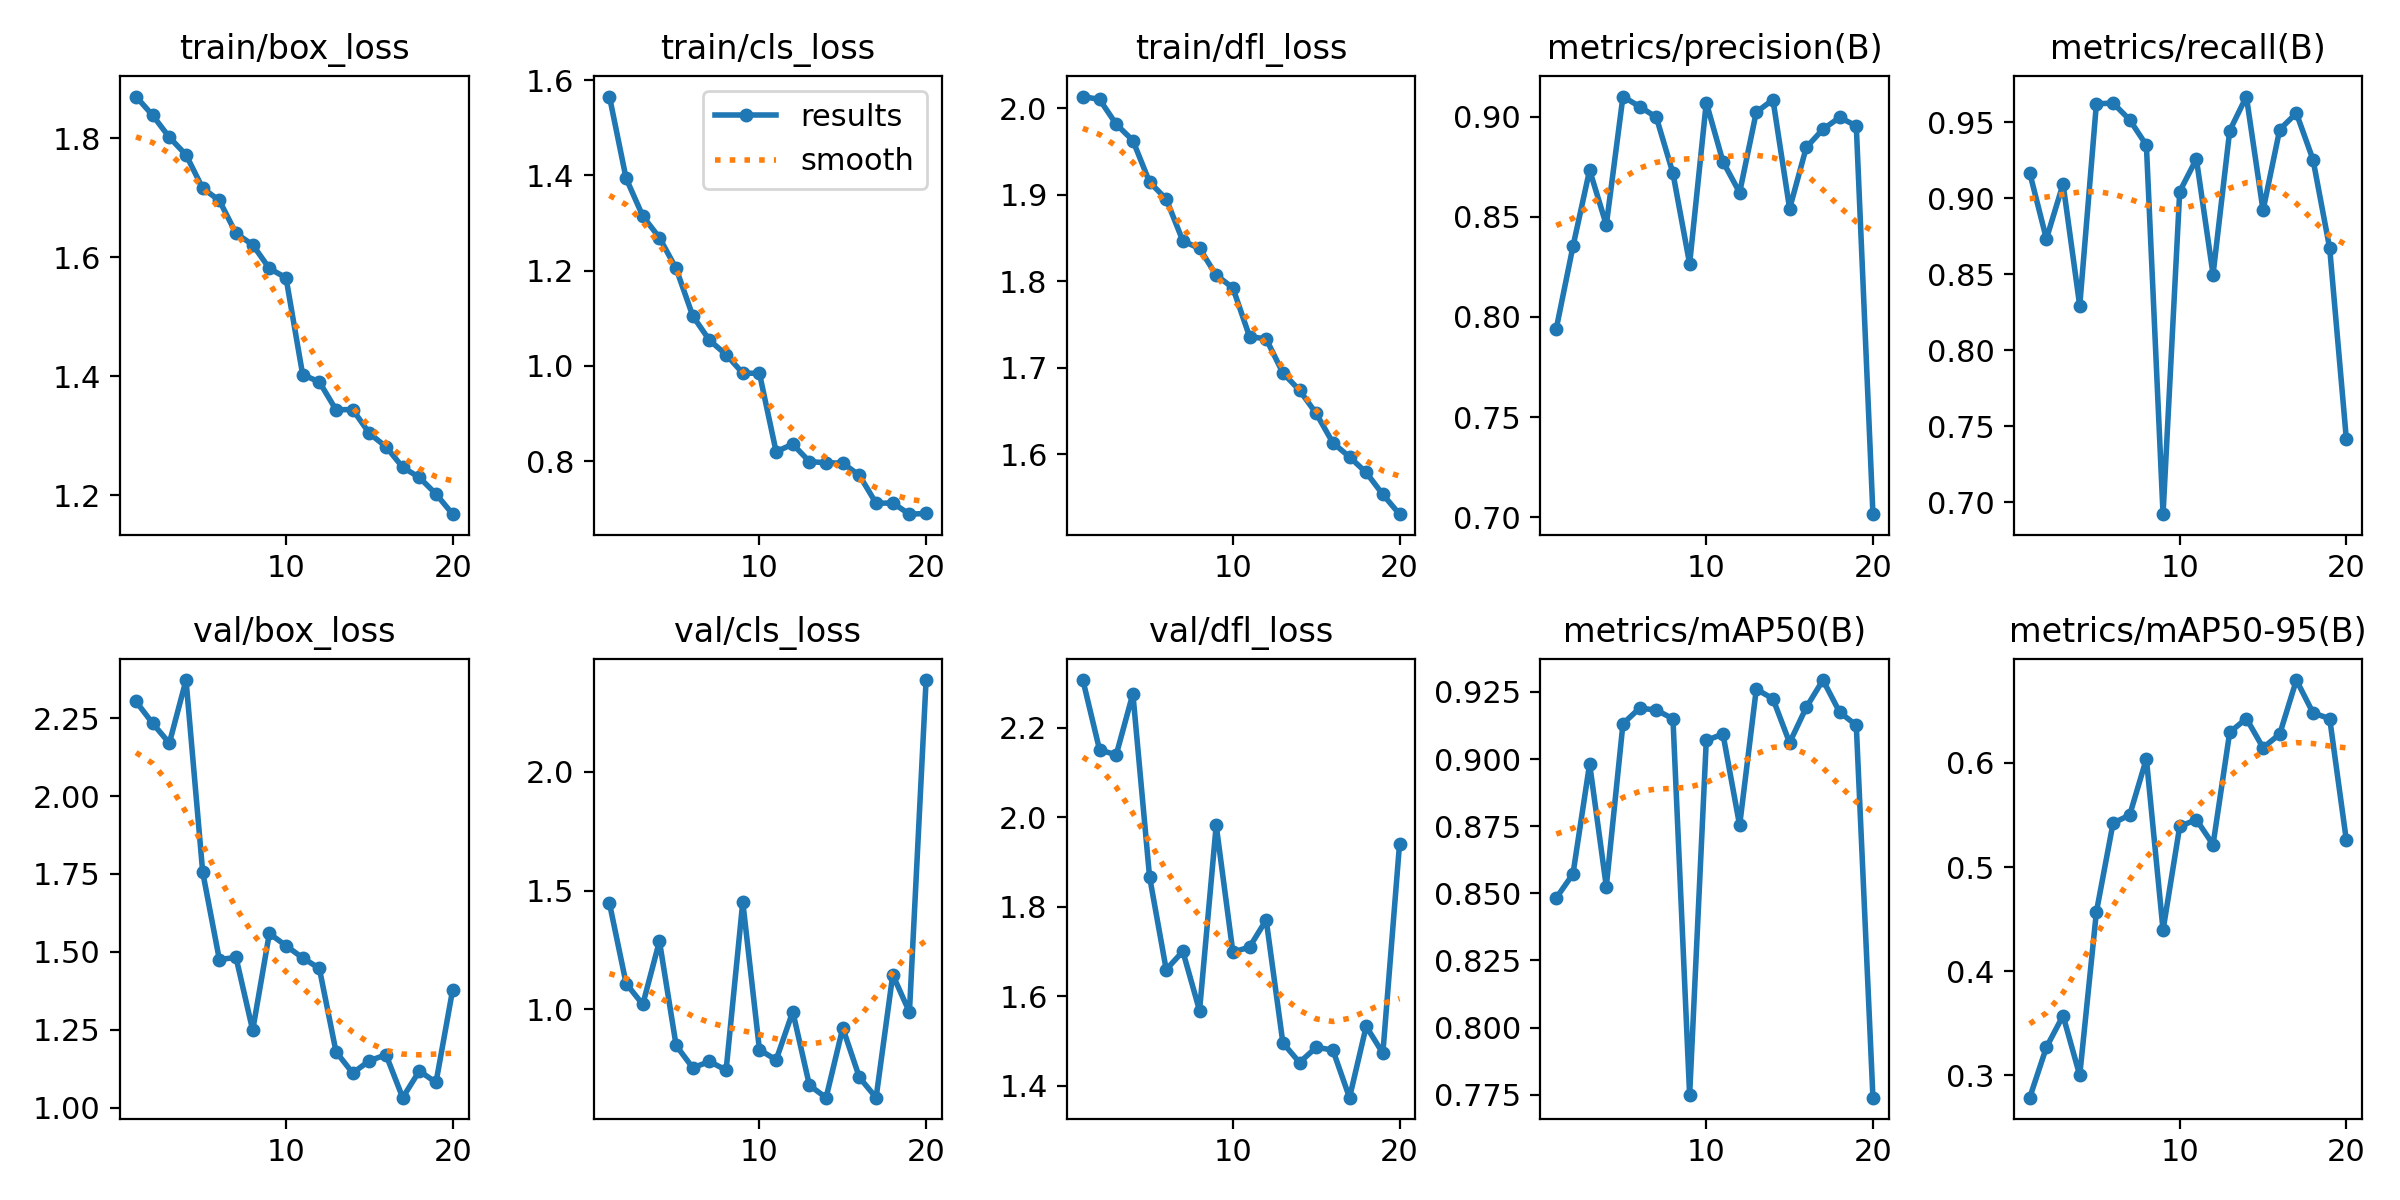

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/results.png', width=600)

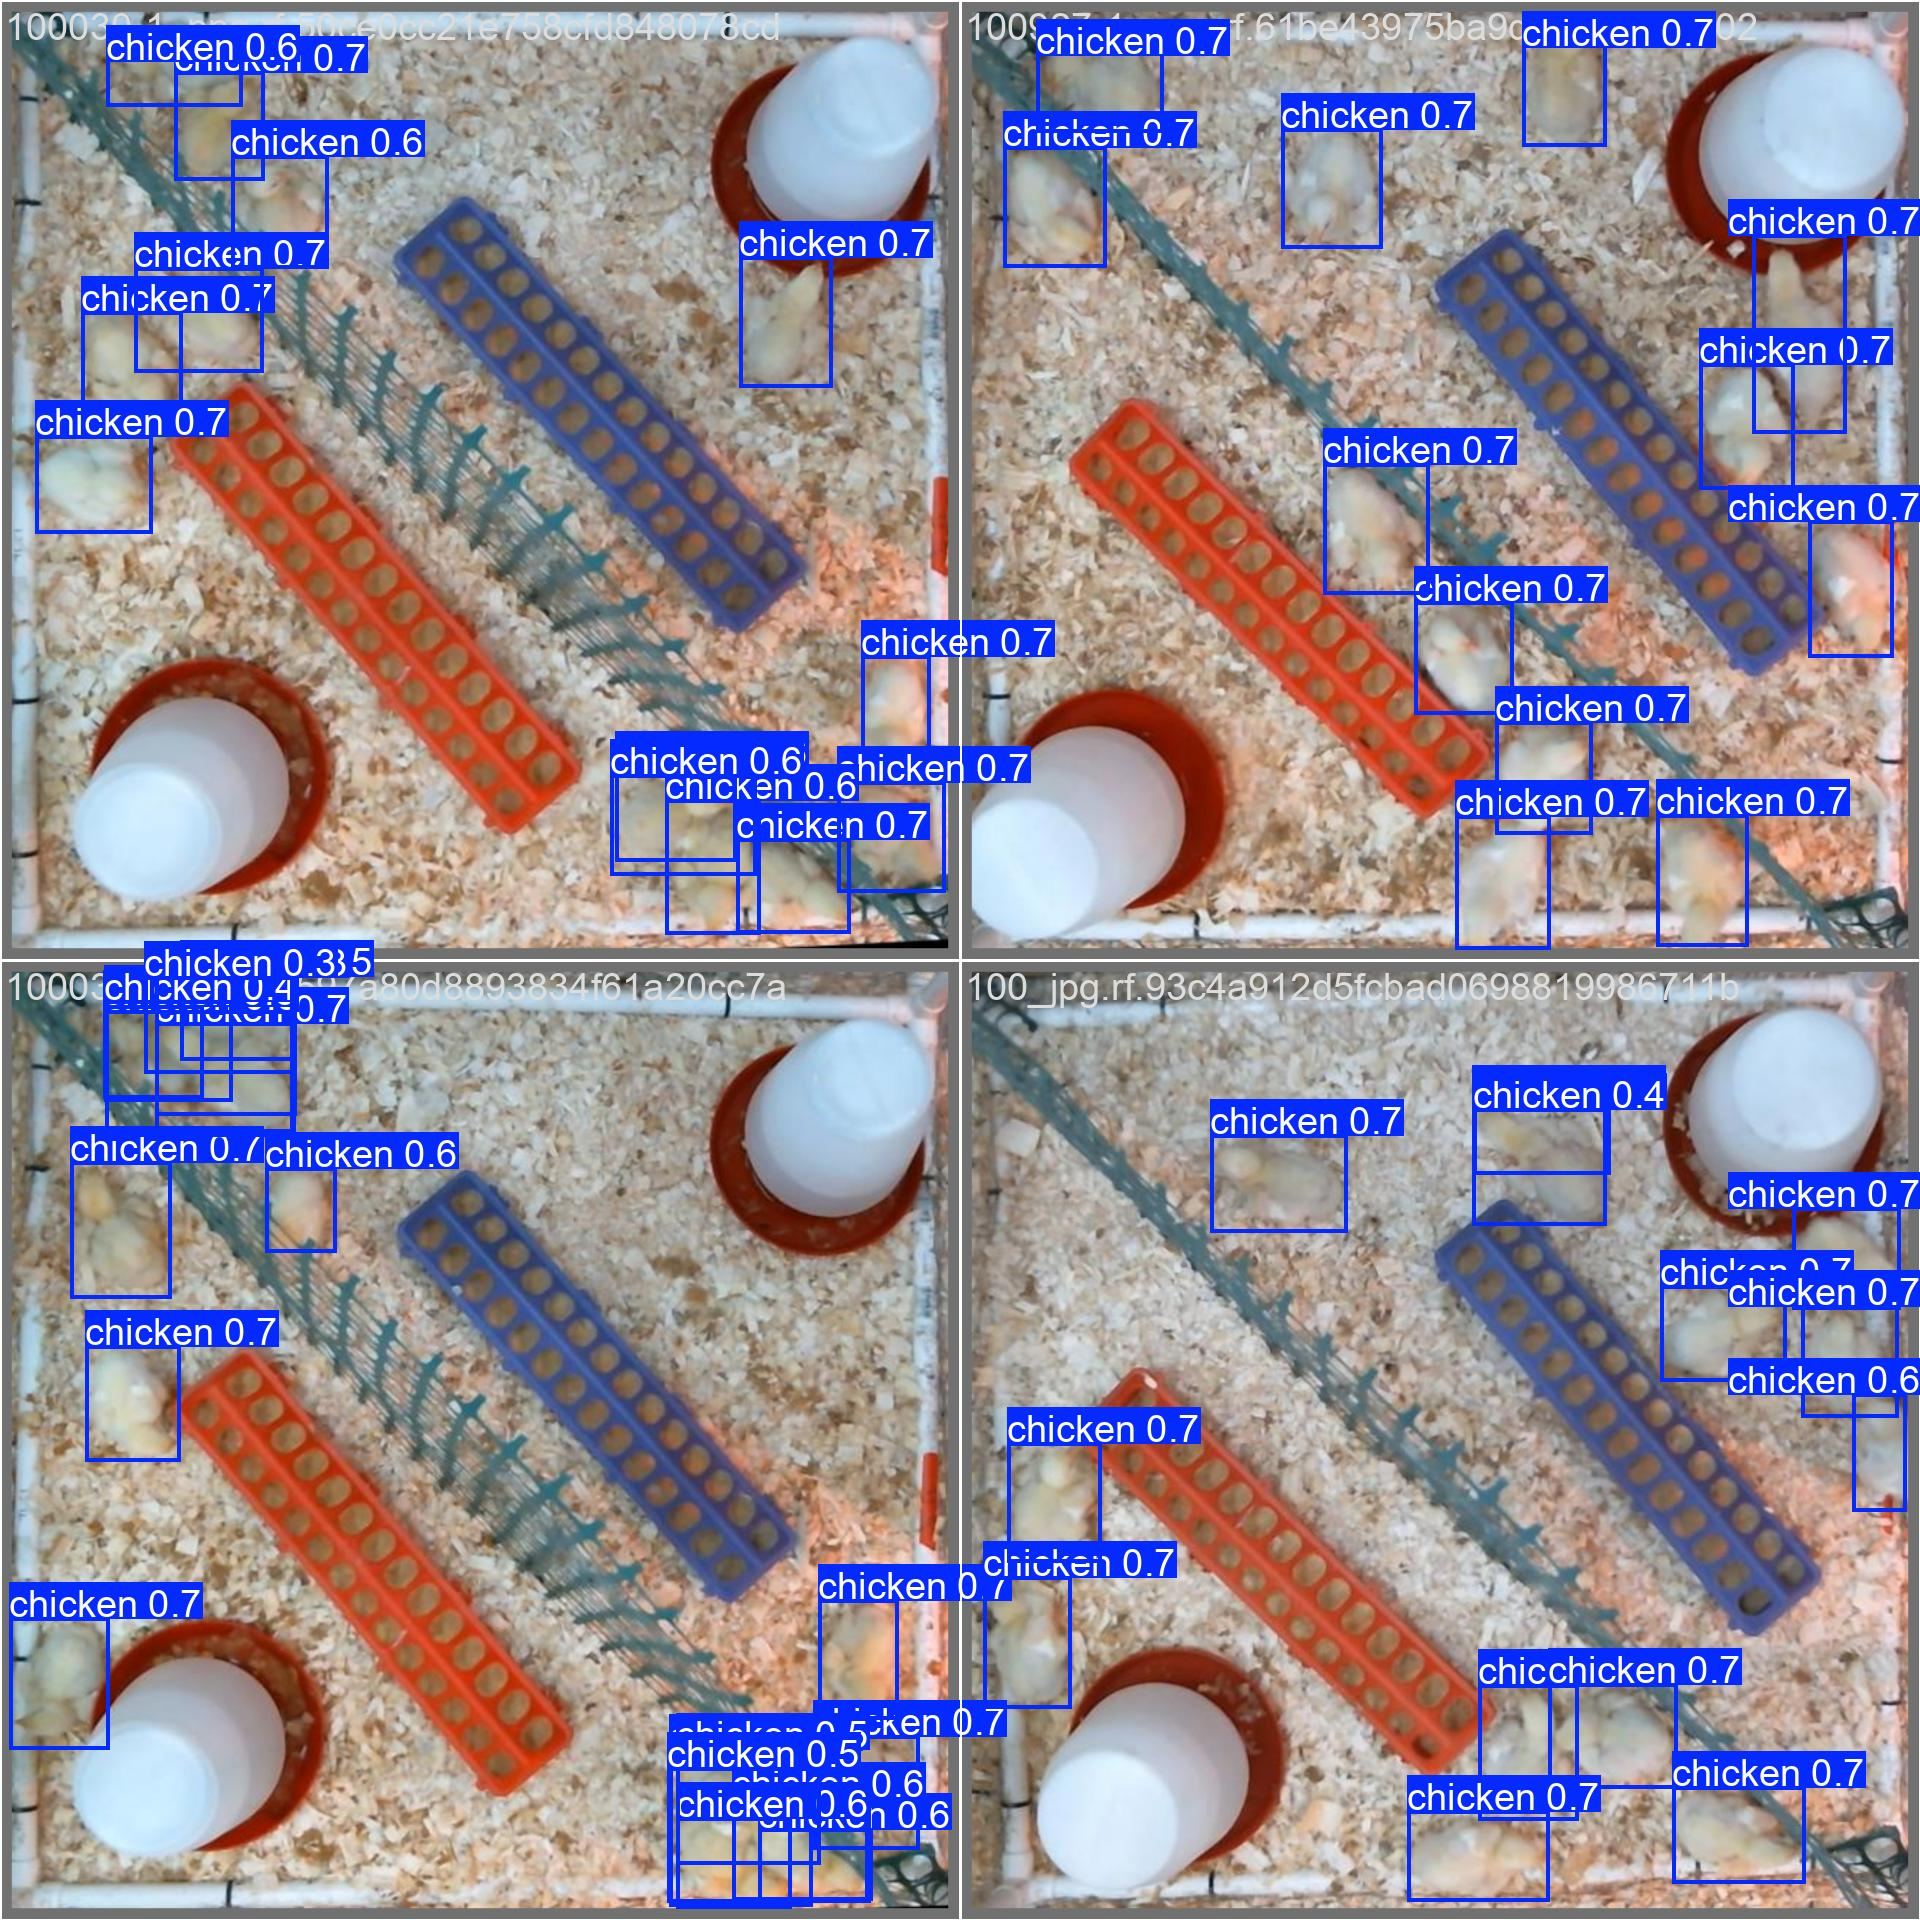

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/roboflow_dataset/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Scanning /content/roboflow_dataset/valid/labels.cache... 188 images, 0 backgrounds, 0 corrupt: 100% 188/188 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 12/12 [00:23<00:00,  1.93s/it]
                   all        188       2092      0.893      0.957       0.93       0.68
Speed: 7.8ms preprocess, 105.6ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.25 source=/content/roboflow_dataset/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs

image 1/177 /content/roboflow_dataset/test/images/100030-2_png.rf.52a2c5f2d3007fb89bfe5a444bbfebe6.jpg: 1280x1280 12 chickens, 105.2ms
image 2/177 /content/roboflow_dataset/test/images/101337-3_png.rf.e1cbe315e514955474be762aa93400be.jpg: 1280x1280 12 chickens, 84.7ms
image 3/177 /content/roboflow_dataset/test/images/101337-7_png.rf.e83a074018244bbcb0e3449aa27a9845.jpg: 1280x1280 12 chickens, 86.7ms
image 4/177 /content/roboflow_dataset/test/images/1022_jpg.rf.9c96b5760bb4d07b7662d5da1ba670dc.jpg: 1280x1280 12 chickens, 87.8ms
image 5/177 /content/roboflow_dataset/test/images/102501-7_png.rf.9f8f62a4ff83c5c1104e046e1552aada.jpg: 1280x1280 12 chickens, 87.1ms
image 6/177 /content/roboflow_dataset/test/images/1026_jpg.rf.39c23a4936ed4669998e73aa16a7576a.jpg: 1280x1280 12 chickens, 86.7ms
image 7/177 /content/roboflow_datas

In [ ]:
import cv2
model = YOLO("/content/runs/detect/train/weights/best.pt")
image = cv2.imread("/content/runs/detect/predict/100030-2_png.rf.52a2c5f2d3007fb89bfe5a444bbfebe6.jpg")
results = model.predict(image)
boxes = results[0].boxes


0: 1280x1280 6 chickens, 95.0ms
Speed: 13.8ms preprocess, 95.0ms inference, 188.9ms postprocess per image at shape (1, 3, 1280, 1280)


In [ ]:
#!yolo predict model=/content/runs/detect/train/weights/best.pt source='https://www.youtube.com/shorts/rsjXjCc173Y' imgsz=320

In [ ]:
!zip -r folder_name.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/predict/ (stored 0%)
  adding: content/runs/detect/predict/1071_jpg.rf.cfa9d268163c91a3a0ca39001e6b11c8.jpg (deflated 3%)
  adding: content/runs/detect/predict/130453-10-_png.rf.034c4c79172e807c7039c58660235242.jpg (deflated 2%)
  adding: content/runs/detect/predict/121833-3-_png.rf.ec5b07bf5f75062ee1d0620aac8db300.jpg (deflated 2%)
  adding: content/runs/detect/predict/100030-2_png.rf.52a2c5f2d3007fb89bfe5a444bbfebe6.jpg (deflated 3%)
  adding: content/runs/detect/predict/131621-6_png.rf.a70f9f66e98b4b88dc7275f9be955c2e.jpg (deflated 2%)
  adding: content/runs/detect/predict/743_jpg.rf.3cddbd4d873d93f4e30c90e7cf0b548e.jpg (deflated 3%)
  adding: content/runs/detect/predict/504_jpg.rf.70ddf3d9009899d23455ca6f1d7d36ef.jpg (deflated 3%)
  adding: content/runs/detect/predict/111_jpg.rf.89cc28169f39a70abbb1a3d5e443faa9.jpg (deflated 3%)
  adding: content/runs/detect/predict/295_jpg.

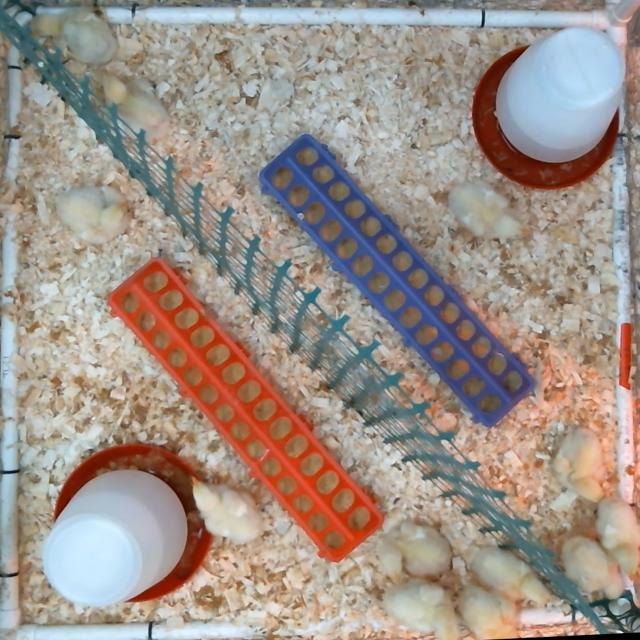


image 1/1 /content/roboflow_dataset/test/images/100030-2_png.rf.52a2c5f2d3007fb89bfe5a444bbfebe6.jpg: 1280x1280 12 chickens, 123.3ms
Speed: 21.7ms preprocess, 123.3ms inference, 4.1ms postprocess per image at shape (1, 3, 1280, 1280)
Detected Chickens: 12
Estimated Weights (kg): [1.0737792504490724, 0.4538694768780967, 1.1303256282784429, 1.0788200899107068, 1.2722063954540976, 0.8345487661383647, 0.880768193417514, 1.1099161000893731, 0.8926634848903328, 0.670404220868174, 1.5972634283765141, 1.0098060448073831]


In [ ]:


# Import libraries
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


def detect_chickens(image_path):
    results = model(image_path)  # Run YOLO detection
    chickens = []  # List to store bounding boxes of chickens
    for result in results:
        for box in result.boxes.data.tolist():  # Extract bounding boxes
            x_min, y_min, x_max, y_max, conf, cls = box
            if int(cls) == 0 and conf > 0.5:  # Check if the class is "chicken" (update class ID based on training)
                chickens.append([x_min, y_min, x_max, y_max])
    return chickens

# Step 3: Calculate Volume and Weight
def calculate_volume_and_weight(bounding_box, pixel_to_cm_ratio, density=0.00105):
    # Bounding box dimensions
    height_pixels = bounding_box[3] - bounding_box[1]
    width_pixels = bounding_box[2] - bounding_box[0]
    depth_pixels = width_pixels * 0.6  # Assumed proportionality for depth

    # Convert dimensions to cm
    height_cm = height_pixels * pixel_to_cm_ratio
    width_cm = width_pixels * pixel_to_cm_ratio
    depth_cm = depth_pixels * pixel_to_cm_ratio

    # Calculate volume (ellipsoid approximation)
    volume_cm3 = (4 / 3) * np.pi * (height_cm / 2) * (width_cm / 2) * (depth_cm / 2)

    # Calculate weight
    weight_kg = volume_cm3 * density
    return volume_cm3, weight_kg

# Step 4: Main Execution
if __name__ == "__main__":
    # Load image
    image_path = "/content/roboflow_dataset/test/images/100030-2_png.rf.52a2c5f2d3007fb89bfe5a444bbfebe6.jpg"  # Update with your image path
    img = cv2.imread(image_path)
    cv2_imshow(img)

    # Detect chickens
    bounding_boxes = detect_chickens(image_path)
    print(f"Detected Chickens: {len(bounding_boxes)}")

    # Set calibration values
    pixel_to_cm_ratio = 0.2  # Adjust based on camera setup and resolution
    density = 0.00105  # Approximate density for chickens (kg/cm³)

    # Calculate weights for all chickens
    weights = []
    for box in bounding_boxes:
        volume_cm3, weight_kg = calculate_volume_and_weight(box, pixel_to_cm_ratio, density)
        weights.append(weight_kg)

    # Display weights
    print("Estimated Weights (kg):", weights)


In [ ]:
def process_image(image_path, pixel_to_cm_ratio=0.2, density=0.00105):
    # Load image
    img = cv2.imread(image_path)
    results = model(image_path)

    # Initialize list for weights
    weights = []
    annotated_image = img.copy()

    # Loop through detections
    for idx, box in enumerate(results[0].boxes.data.tolist()):
        x_min, y_min, x_max, y_max, conf, cls = box

        # Filter only chicken class with high confidence
        if int(cls) == 0 and conf > 0.5:
            # Calculate dimensions in pixels
            height_pixels = y_max - y_min
            width_pixels = x_max - x_min
            depth_pixels = width_pixels * 0.6  # Assuming depth proportionality

            # Convert dimensions to centimeters
            height_cm = height_pixels * pixel_to_cm_ratio
            width_cm = width_pixels * pixel_to_cm_ratio
            depth_cm = depth_pixels * pixel_to_cm_ratio

            # Calculate volume using ellipsoid approximation
            volume_cm3 = (4 / 3) * np.pi * (height_cm / 2) * (width_cm / 2) * (depth_cm / 2)

            # Calculate weight
            weight_kg = volume_cm3 * density
            weights.append(weight_kg)

            # Annotate the image
            label = f"Hen {idx + 1}: {weight_kg:.2f} kg"
            cv2.rectangle(annotated_image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)
            cv2.putText(annotated_image, label, (int(x_min), int(y_min) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    return annotated_image, weights


In [ ]:
# Import libraries
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load YOLO model
model = YOLO("/content/runs/detect/train/weights/best.pt")
 # Replace with your trained YOLO model path

# Detect chickens and calculate weights
def process_image(image_path, pixel_to_cm_ratio=0.2, density=0.00105):
    # Load image
    img = cv2.imread(image_path)
    results = model(image_path)  # YOLO inference

    # Initialize list for weights
    weights = []
    annotated_image = img.copy()

    # Loop through detections
    for idx, box in enumerate(results[0].boxes.data.tolist()):  # Iterate through detected boxes
        x_min, y_min, x_max, y_max, conf, cls = box

        # Filter only chicken class (update `cls` to match your chicken class ID if necessary)
        if int(cls) == 0 and conf > 0.5:  # Adjust confidence threshold if needed
            # Calculate dimensions
            height_pixels = y_max - y_min
            width_pixels = x_max - x_min
            depth_pixels = width_pixels * 0.6  # Assumed depth proportionality

            # Convert to cm
            height_cm = height_pixels * pixel_to_cm_ratio
            width_cm = width_pixels * pixel_to_cm_ratio
            depth_cm = depth_pixels * pixel_to_cm_ratio

            # Calculate volume (ellipsoid approximation)
            volume_cm3 = (4 / 3) * np.pi * (height_cm / 2) * (width_cm / 2) * (depth_cm / 2)

            # Calculate weight
            weight_kg = volume_cm3 * density
            weights.append(weight_kg)

            # Annotate the image
            label = f"Hen {idx + 1}: {weight_kg:.2f} kg"
            cv2.rectangle(annotated_image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)
            cv2.putText(annotated_image, label, (int(x_min), int(y_min) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    return annotated_image, weights

# Main execution
if __name__ == "__main__":
    # Input image path
    image_path = "/content/A-large-scale-poultry-farm.webp"  # Replace with your image path

    # Process image
    annotated_image, weights = process_image(image_path)

    # Display annotated image
    print("Estimated Weights (kg):", weights)
    cv2_imshow(annotated_image)  # Show annotated image in Colab
    cv2.imwrite("/content/annotated_chickens.jpg", annotated_image)

FileNotFoundError: /content/A-large-scale-poultry-farm.webp does not exist

In [ ]:
import cv2
# Weight prediction model (dummy function for now)
def predict_weight(bbox):
    # Assuming bbox contains (x, y, w, h)
    # You can replace this with a more sophisticated model
    _, _, w, h = bbox
    return 0.5 * (w + h)  # Replace with your actual weight estimation logic

# Real-time video stream
camera = cv2.VideoCapture(0)  # Change to video file path if needed

if not camera.isOpened():
    print("Error: Could not access the camera.")
    exit()

while True:
    ret, frame = camera.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    # Convert frame to YOLO input format
    input_image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_image = cv2.resize(input_image, (640, 640))  # Resize to model input size

    # Perform inference
    results = model.predict(input_image)

    chicken_count = 0
    for detection in results:
        if detection["label"] == "chicken":  # Assuming 'chicken' is a class in your model
            chicken_count += 1

            # Get bounding box and weight
            bbox = detection["bbox"]  # (x, y, w, h)
            weight = predict_weight(bbox)

            # Draw bounding box and label on the frame
            x, y, w, h = map(int, bbox)
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            label = f"Hen {chicken_count}: {weight:.2f}kg"
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Display chicken count on the frame
    cv2.putText(
        frame,
        f"Total Chickens: {chicken_count}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2,
    )

    # Show the frame (commented out as it's unsupported in headless environments)
    # cv2.imshow("Chicken Counter", frame)

    # Optional: save or process the frame if display is not possible

    # Break loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
camera.release()
# Commented out since destroyAllWindows isn't supported without display backend
# cv2.destroyAllWindows()


In [ ]:
# import cv2
# cv2.imwrite("processed_frame.jpg", frame)


In [ ]:
from flask import Flask, Response, render_template
import cv2
import numpy as np


app = Flask(__name__)


def predict_weight(bbox):
    _, _, w, h = bbox
    return 0.5 * (w + h)

def generate_frames():
    camera = cv2.VideoCapture(0)
    if not camera.isOpened():
        print("Error: Could not access the camera.")
        return

    while True:
        ret, frame = camera.read()
        if not ret:
            break

        # Process frame
        input_image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        input_image = cv2.resize(input_image, (640, 640))

        results = model.predict(input_image)
        chicken_count = 0

        for detection in results:
            if detection["label"] == "chicken":
                chicken_count += 1
                bbox = detection["bbox"]
                weight = predict_weight(bbox)

                x, y, w, h = map(int, bbox)
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                label = f"Hen {chicken_count}: {weight:.2f}kg"
                cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        cv2.putText(frame, f"Total Chickens: {chicken_count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        # Encode frame for streaming
        _, buffer = cv2.imencode(".jpg", frame)
        frame = buffer.tobytes()

        yield (b'--frame\r\n'
               b'Content-Type: image/jpeg\r\n\r\n' + frame + b'\r\n')

    camera.release()

@app.route('/video_feed')
def video_feed():
    return Response(generate_frames(), mimetype='multipart/x-mixed-replace; boundary=frame')

@app.route('/')
def index():
    return render_template('/content/index.html')  # Create a simple index.html for the webpage

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)


In [ ]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO

# Load the model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Define the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load video
video_path = "/content/238355c138d64263953be5b216ee15c4.mp4"
output_path = "/content/output_video.mp4"
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Chicken class index (update if needed)
chicken_class_id = 0

# Process video frame by frame
frame_index = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess frame
    input_image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    input_image = cv2.resize(input_image, (640, 640))  # Resize to YOLOv11 input size

    # Perform inference
    results = model(input_image)  # Get results from the model

    # Count chickens and annotate frame
    chicken_count = 0
    for *xyxy, conf, cls in results[0].boxes.data:  # Iterate through detected boxes
        if int(cls) == chicken_class_id and conf > 0.5:  # Confidence threshold
            chicken_count += 1

            # Convert to integer coordinates for bounding box
            x1, y1, x2, y2 = map(int, xyxy)

            # Draw bounding box and labels
            color = (0, 255, 0)  # Green for bounding boxes
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Add chicken serial number (weight is not directly available)
            label = f"Chicken {chicken_count}"
            cv2.putText(
                frame,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),  # Red text
                1,
            )

    # Display chicken count on the frame
    count_label = f"Total Chickens: {chicken_count}"
    cv2.putText(
        frame,
        count_label,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),  # Yellow text
        2,
    )

    # Write frame to output video
    out.write(frame)
    frame_index += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()
print(f"Output video saved to {output_path}")

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/runs/detect/train/weights/best.pt")
results = model.predict("/content/1000-broiler-chickens1.webp", augment=True)
print(results)

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Run prediction with augmentation (TTA)
results = model.predict("/content/1000-broiler-chickens1.webp", augment=True)

# Get the plotted image with bounding boxes
plotted_image = results[0].plot()  # Returns BGR image with annotations

# Convert BGR to RGB for matplotlib
plotted_image_rgb = plotted_image[:, :, ::-1]

# Display using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(plotted_image_rgb)
plt.axis('off')
plt.show()